In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from astropy.table import Table
import seaborn as sns
import matplotlib as mpl


In [2]:

hdulist = fits.open("../anac_data/CIGALE-test/out/observations.fits")
data = hdulist[1].data  # La tabla
print(data.columns)

ColDefs(
    name = 'id'; format = '8A'
    name = 'redshift'; format = 'D'
    name = 'F0378'; format = 'D'
    name = 'F0378_err'; format = 'D'
    name = 'F0395'; format = 'D'
    name = 'F0395_err'; format = 'D'
    name = 'F0410'; format = 'D'
    name = 'F0410_err'; format = 'D'
    name = 'F0430'; format = 'D'
    name = 'F0430_err'; format = 'D'
    name = 'F0515'; format = 'D'
    name = 'F0515_err'; format = 'D'
    name = 'F0660'; format = 'D'
    name = 'F0660_err'; format = 'D'
    name = 'F0861'; format = 'D'
    name = 'F0861_err'; format = 'D'
)


In [3]:
def plot_splus_gc_sed_with_residuals(obj_id, 
                                    observations_file='../anac_data/CIGALE-test/out/observations.fits', 
                                    results_file='../anac_data/CIGALE-test/out/results.fits',
                                    output_dir='../anac_data/CIGALE-test/'):
    """
    Gráfico SED especializado para cúmulos globulares con filtros S-PLUS
    
    Parameters:
    -----------
    obj_id : str or int
        ID del objeto (cúmulo globular)
    observations_file : str
        Ruta al archivo observations.fits de CIGALE
    results_file : str
        Ruta al archivo results.fits de CIGALE  
    output_dir : str
        Directorio donde guardar el gráfico
    """
    
    try:
        # Leer archivos de CIGALE
        model = Table.read(f'../anac_data/CIGALE-test/out/{obj_id}_best_model.fits')
        obs = Table.read(observations_file)
        results = Table.read(results_file)
        
        # Filtrar datos para el objeto específico
        obs_obj = obs[obs['id'] == obj_id]
        res_obj = results[results['id'] == obj_id]
        
        # Obtener parámetros físicos clave - usando las columnas correctas
        reduced_chi2 = res_obj['best.reduced_chi_square'][0]
        stellar_mass = res_obj['best.stellar.m_star'][0]
        metallicity = res_obj['best.stellar.metallicity'][0]
        age = res_obj['best.stellar.age_m_star'][0]
        
        print(f"📊 Analizando objeto {obj_id}:")
        print(f"   Masa estelar: {stellar_mass:.2e} M_sun")
        print(f"   Metalicidad: {metallicity:.4f}")
        print(f"   Edad: {age:.0f} Myr")
        print(f"   χ² reducido: {reduced_chi2:.2f}")
        
    except FileNotFoundError as e:
        print(f"❌ Error: Dont find the  {obj_id}")
        print(f"   Asegúrate de que existe: ../anac_data/CIGALE-test/out/{obj_id}_best_model.fits")
        return
    except Exception as e:
        print(f"❌ Error leyendo archivos: {e}")
        return

    # Configurar el gráfico con estilo para publicación
    plt.style.use('default')  # Reset para tener control total
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                  gridspec_kw={'height_ratios': [2, 1]})
    
    # Convertir nm a μm para mejor visualización
    wavelength_um = model['wavelength'] / 1000.0
    
    # --- Panel 1: SED completo ---
    # Modelo total - línea más fina y elegante
    ax1.loglog(wavelength_um, model['Fnu'], 'k-', linewidth=1.5, 
              label='Total Model', alpha=0.9)
    
    # Componentes (ajustados para cúmulos globulares)
    if 'stellar' in model.colnames:
        ax1.loglog(wavelength_um, model['stellar'], 'steelblue', alpha=0.6, 
                  linewidth=1.0, label='Stellar Component', linestyle='--')
    
    # Filtros S-PLUS con sus longitudes de onda efectivas
    splus_filters = {
        'F0378': (0.378, '#4A148C', 'J0378'),  # Púrpura oscuro
        'F0395': (0.395, '#6A1B9A', 'J0395'),  # Púrpura  
        'F0410': (0.410, '#283593', 'J0410'),  # Azul índigo
        'F0430': (0.430, '#0277BD', 'J0430'),  # Azul
        'F0515': (0.515, '#00897B', 'J0515'),  # Verde azulado
        'F0660': (0.660, '#E65100', 'J0660'),  # Naranja oscuro
        'F0861': (0.861, '#BF360C', 'J0861')   # Rojo oscuro
    }
    
    residuals_data = []
    
    for filter_name, (wave, color, band_short) in splus_filters.items():
        if filter_name in obs_obj.colnames:
            # Flujo observado
            flux_obs = obs_obj[filter_name][0]
            flux_err = obs_obj[filter_name + '_err'][0]
            
            # Flujo del modelo (en results)
            model_flux_col = f'best.{filter_name}'
            if model_flux_col in res_obj.colnames:
                flux_model = res_obj[model_flux_col][0]
                
                # Calcular residuo normalizado
                residual = (flux_obs - flux_model) / flux_err
                
                # Plot observación - CUADRADOS VACÍOS MÁS GRANDES
                # CORRECCIÓN: Añadir ecolor=color para que las barras de error coincidan
                ax1.errorbar(wave, flux_obs, yerr=flux_err, 
                            fmt='s', markerfacecolor='none', markeredgecolor=color, 
                            markersize=10, capsize=3, markeredgewidth=1.5,
                            ecolor=color,  # ¡ESTA LÍNEA FALTABA!
                            label=f'Obs {band_short}', alpha=0.9, zorder=5)
                
                # Plot flujo del modelo - CÍRCULOS SÓLIDOS DE COLOR ATRACTIVO
                ax1.plot(wave, flux_model, marker='o', markersize=6, 
                        markerfacecolor='#E91E63', markeredgecolor='#E91E63', 
                        linestyle='', label=f'Model fluxes', alpha=0.9, zorder=4)
                
                # Guardar datos para residuos
                residuals_data.append({
                    'band': band_short,
                    'filter_name': filter_name,
                    'wave': wave,
                    'obs': flux_obs,
                    'model': flux_model, 
                    'error': flux_err,
                    'residual': residual,
                    'color': color
                })
    
    # Configurar panel 1 - Estilo para publicación
    ax1.set_xlabel('Wavelength (μm)', fontsize=14, fontweight='normal')  # Corregí el typo
    ax1.set_ylabel('Flux (mJy)', fontsize=14, fontweight='normal')
    
    # Título más limpio para publicación
    title_text = (f'GC {obj_id} | '
                 f'M = {stellar_mass:.2e} M$_\odot$ | '
                 f'Z = {metallicity:.4f} | '
                 f'Age = {age/1000:.1f} Gyr | '  # Cambié "Edad" por "Age" para consistencia
                 f'$\chi^2$ = {reduced_chi2:.2f}')
    ax1.set_title(title_text, fontsize=10, pad=10)
    
    # Leyenda mejorada y compacta
    handles, labels = ax1.get_legend_handles_labels()
    # Mantener solo una entrada por tipo (no duplicados por filtro)
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    # Ordenar leyenda: primero componentes del modelo, luego observaciones
    model_handles = [h for h, l in zip(unique_handles, unique_labels) if 'Model' in l or 'Component' in l]
    model_labels = [l for l in unique_labels if 'Model' in l or 'Component' in l]
    obs_handles = [h for h, l in zip(unique_handles, unique_labels) if 'Obs' in l]
    obs_labels = [l for l in unique_labels if 'Obs' in l]
    
    # Reconstruir leyenda ordenada
    ordered_handles = model_handles + obs_handles
    ordered_labels = model_labels + obs_labels
    
    ax1.legend(ordered_handles, ordered_labels, loc='best', 
              ncol=2, fontsize=10, framealpha=0.9, fancybox=True)
    
    ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax1.set_xlim(0.3, 1.0)
    ax1.xaxis.set_visible(False) 
    ax1.set_yticklabels(ax1.get_yticks(), fontsize=12) 


    
    # Ajuste automático del rango Y
    if residuals_data:
        all_fluxes = [d['obs'] for d in residuals_data] + [d['model'] for d in residuals_data]
        min_flux = min(all_fluxes) * 0.3
        max_flux = max(all_fluxes) * 3.0
        ax1.set_ylim(min_flux, max_flux)
    
    # --- Panel 2: Residuos ---
    if residuals_data:
        bands = [d['band'] for d in residuals_data]
        waves = [d['wave'] for d in residuals_data]
        residuals = [d['residual'] for d in residuals_data]
        colors = [d['color'] for d in residuals_data]
        
        # Plot residuos - mantener colores originales de filtros
        for i, (band, wave, residual, color) in enumerate(zip(bands, waves, residuals, colors)):
            ax2.scatter(wave, residual, color=color, s=80, zorder=3, 
                       marker='s', label=f'{band}', alpha=0.8, edgecolors='black', linewidth=0.5)
            
            # Conectar puntos con líneas para mejor visualización
            if i > 0:
                prev_wave = waves[i-1]
                prev_residual = residuals[i-1]
                ax2.plot([prev_wave, wave], [prev_residual, residual], 
                        'gray', alpha=0.3, linestyle='-', linewidth=1)
        
        # Líneas de referencia más sutiles
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
        ax2.axhline(y=1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=-1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        ax2.axhline(y=-2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        
        ax2.set_xlabel('Wavelength (μm)', fontsize=14, fontweight='normal')  # Corregí el typo
        ax2.set_ylabel('Residual (σ)', fontsize=14, fontweight='normal')
        ax2.tick_params(axis='both', which='major', labelsize=26)
        #ax2.set_title('Residual: (Observado - Modelo) / Error', fontsize=10, pad=8)
        ax2.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
        ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax2.set_xscale('log')
        ax2.set_xlim(0.3, 1.0) 
        
        # Ajustar límites Y para residuos
        max_res = max(3, max(np.abs(residuals)) * 1.2)
        ax2.set_ylim(-max_res, max_res)
        ax2.tick_params(axis='both', which='major', labelsize=26)
    
    # Ajustes finales de estilo
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.tick_params(axis='both', which='minor', labelsize=14)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.01)  # Menos espacio entre subplots
    
    # Guardar gráfico con alta calidad para publicación
    output_path = f'{output_dir}/{obj_id}_SED_S-PLUS.png'
    output_path1 = f'{output_dir}/{obj_id}_SED_S-PLUS.pdf'
    plt.savefig(output_path, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    plt.savefig(output_path1, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    print(f"✅ Gráfico guardado: {output_path}")
    plt.show()
    
    # Imprimir tabla de residuos detallada
    if residuals_data:
        print(f"\n{'='*60}")
        print(f"ANÁLISIS DE RESIDUOS - Cúmulo Globular {obj_id}")
        print(f"{'='*60}")
        print(f"{'Filtro':<8} {'λ (μm)':<8} {'Obs (mJy)':<12} {'Model (mJy)':<12} {'Residuo (σ)':<12} {'|Residuo|':<10}")
        print(f"{'-'*60}")
        
        for data in residuals_data:
            abs_residual = abs(data['residual'])
            print(f"{data['band']:<8} {data['wave']:<8.3f} {data['obs']:<12.6f} "
                  f"{data['model']:<12.6f} {data['residual']:<12.2f} {abs_residual:<10.2f}")
        
        print(f"{'-'*60}")
        avg_abs_residual = np.mean([abs(d['residual']) for d in residuals_data])
        print(f"Residuo absoluto promedio: {avg_abs_residual:.2f}σ")
        print(f"Número de puntos: {len(residuals_data)}")
        print(f"{'='*60}")

# Función auxiliar para plotear múltiples objetos
def plot_multiple_gcs(obj_ids, **kwargs):
    """
    Plotear SEDs para múltiples cúmulos globulares
    
    Parameters:
    -----------
    obj_ids : list
        Lista de IDs de objetos a plotear
    **kwargs : 
        Argumentos adicionales para plot_splus_gc_sed_with_residuals
    """
    for obj_id in obj_ids:
        print(f"\n{'#'*50}")
        print(f"PROCESANDO OBJETO: {obj_id}")
        print(f"{'#'*50}")
        plot_splus_gc_sed_with_residuals(obj_id, **kwargs)

<>:126: SyntaxWarning: invalid escape sequence '\o'
<>:129: SyntaxWarning: invalid escape sequence '\c'
<>:126: SyntaxWarning: invalid escape sequence '\o'
<>:129: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3853073/3731239610.py:126: SyntaxWarning: invalid escape sequence '\o'
  f'M = {stellar_mass:.2e} M$_\odot$ | '
/tmp/ipykernel_3853073/3731239610.py:129: SyntaxWarning: invalid escape sequence '\c'
  f'$\chi^2$ = {reduced_chi2:.2f}')


📊 Analizando objeto T17-2602:
   Masa estelar: 2.69e+03 M_sun
   Metalicidad: 0.0040
   Edad: 9980 Myr
   χ² reducido: 0.36


/tmp/ipykernel_3853073/3731239610.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), fontsize=12)


✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2602_SED_S-PLUS.png


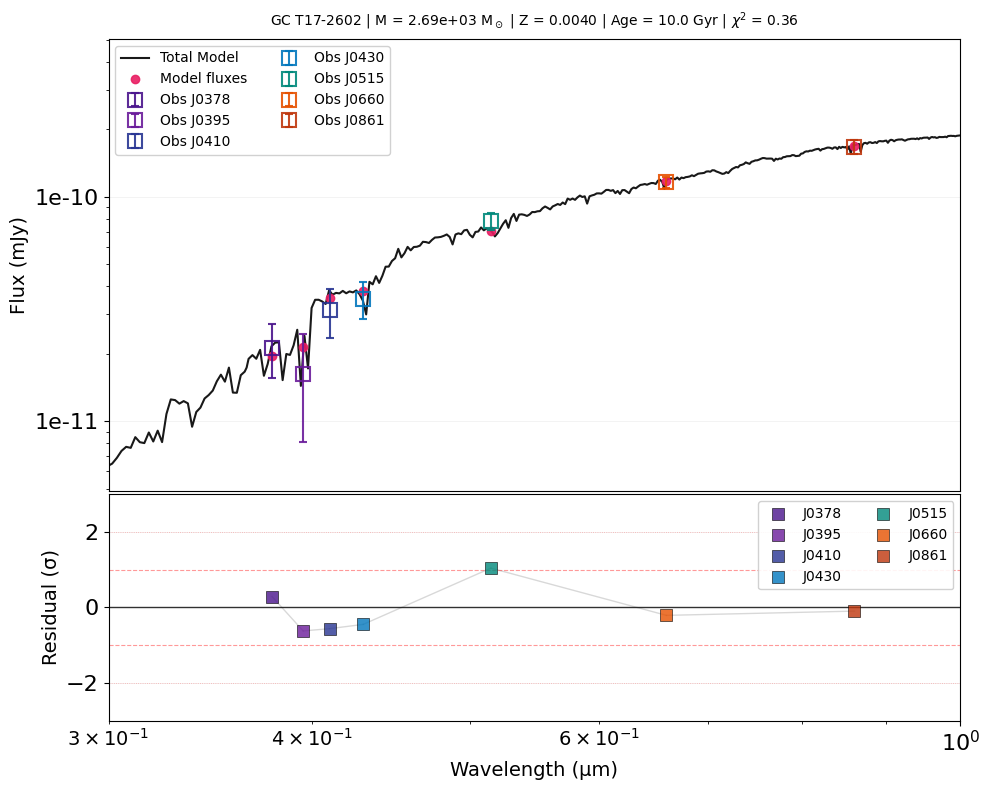


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2602
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.000021     0.000020     0.29         0.29      
J0395    0.395    0.000016     0.000021     -0.62        0.62      
J0410    0.410    0.000031     0.000036     -0.56        0.56      
J0430    0.430    0.000035     0.000038     -0.45        0.45      
J0515    0.515    0.000078     0.000071     1.05         1.05      
J0660    0.660    0.000117     0.000118     -0.21        0.21      
J0861    0.861    0.000167     0.000168     -0.10        0.10      
------------------------------------------------------------
Residuo absoluto promedio: 0.47σ
Número de puntos: 7


In [8]:
# Ejemplo de uso:
if __name__ == "__main__":
    # Plotear un objeto individual
    plot_splus_gc_sed_with_residuals('T17-2602')


## Other example

📊 Analizando objeto T17-2211:
   Masa estelar: 5.51e+02 M_sun
   Metalicidad: 0.0200
   Edad: 2022 Myr
   χ² reducido: 0.06


/tmp/ipykernel_3853073/3731239610.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), fontsize=12)


✅ Gráfico guardado: ../anac_data/CIGALE-test//T17-2211_SED_S-PLUS.png


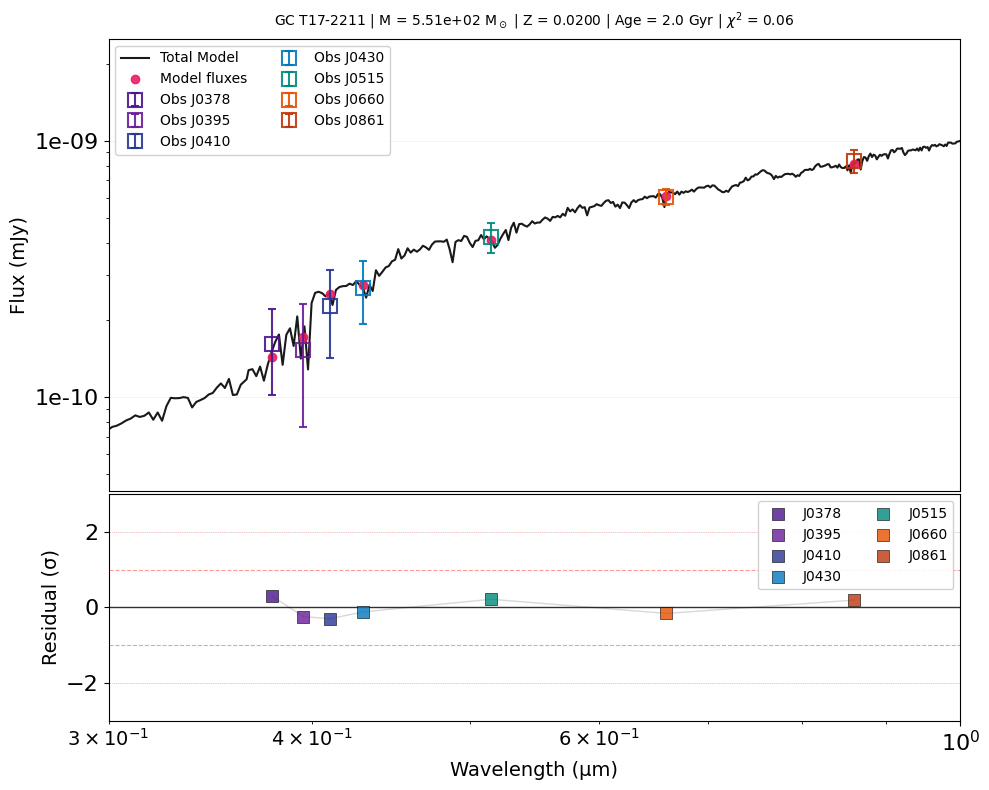


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2211
Filtro   λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
------------------------------------------------------------
J0378    0.378    0.000016     0.000014     0.31         0.31      
J0395    0.395    0.000015     0.000017     -0.24        0.24      
J0410    0.410    0.000023     0.000025     -0.30        0.30      
J0430    0.430    0.000027     0.000027     -0.12        0.12      
J0515    0.515    0.000042     0.000041     0.22         0.22      
J0660    0.660    0.000060     0.000061     -0.16        0.16      
J0861    0.861    0.000083     0.000081     0.20         0.20      
------------------------------------------------------------
Residuo absoluto promedio: 0.22σ
Número de puntos: 7


In [5]:
plot_splus_gc_sed_with_residuals('T17-2211')